In [1]:
import ROOT
import matplotlib as mpl
mpl.rcParams['axes.unicode_minus']=False
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.ticker as ticker
import mplhep as hep
from sklearn.neighbors import KernelDensity

In [2]:
hep.style.use(hep.style.ATLAS)
plt.rcParams.update({
    'figure.figsize': (8, 6), 
    'figure.dpi': 150, 
    'figure.facecolor':'white',

    #font
    'font.family': 'Times New Roman',
    'font.size': 12, 
    'axes.titlesize': 14, 
    'axes.labelsize': 12,
    'xtick.labelsize':12,
    'ytick.labelsize':12,
    'legend.fontsize':12,
    'axes.linewidth':1.2,
    'axes.grid':False,
    # Ticks — ROOT-like: inward, 4-sided, with minor ticks
    'xtick.top'           : True,
    'ytick.right'         : True,
    'xtick.minor.visible' : True,
    'ytick.minor.visible' : True,
    'xtick.direction'     : 'in',
    'ytick.direction'     : 'in',
    'xtick.major.size'    : 6,
    'xtick.minor.size'    : 3,
    'ytick.major.size'    : 6,
    'ytick.minor.size'    : 3,
    'xtick.major.width'   : 1.2,
    'ytick.major.width'   : 1.2,

    # Lines & markers
    'lines.linewidth'     : 1.8,
    'lines.markersize'    : 5,

    # Legend
    'legend.frameon'      : False,
    
    # Saving
    'savefig.dpi'         : 300,
    'savefig.bbox'        : 'tight',
    'savefig.facecolor'   : 'white',
})
# --- Colorblind-friendly HEP palette ---
HEP_COLORS = [
    '#0077BB',   # blue
    '#EE3377',   # magenta
    '#009988',   # teal
    '#EE7733',   # orange
    '#AA3377',   # purple
    '#BBBBBB',   # grey  (backgrounds, MC)
]
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=HEP_COLORS)

In [4]:
ls ../ -lh -t

total 26G
drwxr-xr-x. 4 rraut rraut 4.0K Mar 22 18:42 script/
-rw-r--r--. 1 rraut rraut 3.8M Mar 22 18:34 Cosmic_MC_3ms.root
-rw-r--r--. 1 rraut rraut 4.6M Mar 22 18:34 Nu_Cosmic_MC_3ms.root
-rw-r--r--. 1 rraut rraut  58K Mar 18 10:53 NU+cosmic_MC_Mergecoll_8M.root
-rw-r--r--. 1 rraut rraut 105K Mar 16 12:38 cosmic_mergecoll.root
-rw-r--r--. 1 rraut rraut 6.9M Mar  4 10:35 Nu+Cosmic_Pdune_1MADC_20kticks.root
-rw-r--r--. 1 rraut rraut 6.0M Mar  4 10:35 Cosmic_Pdune_1MADC_20kticks_10k.root
-rw-r--r--. 1 rraut rraut 6.2M Mar  2 16:39 Nu_MC_1e6thr.root
-rw-r--r--. 1 rraut rraut  12G Feb 24 00:10 Cosmic_detsim_reco_99.root
-rw-r--r--. 1 rraut rraut 493M Feb  8 23:05 Run39350_BDE_Reco_stage1_100.root
-rw-r--r--. 1 rraut rraut 1.6G Feb  7 14:28 Run039636_BDE_Reco_stage1_100.root
-rw-r--r--. 1 rraut rraut 567M Feb  7 12:18 Run39543_BDE_Reco_stage1_100.root
-rw-r--r--. 1 rraut rraut 223M Feb  5 16:22 PDVD_CosmicOnly_yk_sample_BDE_Reco_stage1.root
-rw-r--r--. 1 rraut rraut 921M Feb  4 14:30 PDVD

In [6]:
TICKS_TO_CM= 0.5*0.16 #0.08 cm/ticks
f_cos = ROOT.TFile.Open("../Cosmic_MC_3ms.root", "READ")
f_nu = ROOT.TFile.Open("../Nu_Cosmic_MC_3ms.root", "READ")
if not f_cos or f_cos.IsZombie() or not f_nu or f_nu.IsZombie():
    raise FileNotFoundError("Error File not found")
tree_cos = f_cos.Get("hitdQ/TATree")
tree_nu = f_nu.Get("hitdQ/TATree")
if not tree_cos or not tree_nu:
    raise ValueError("Error the branch not found")


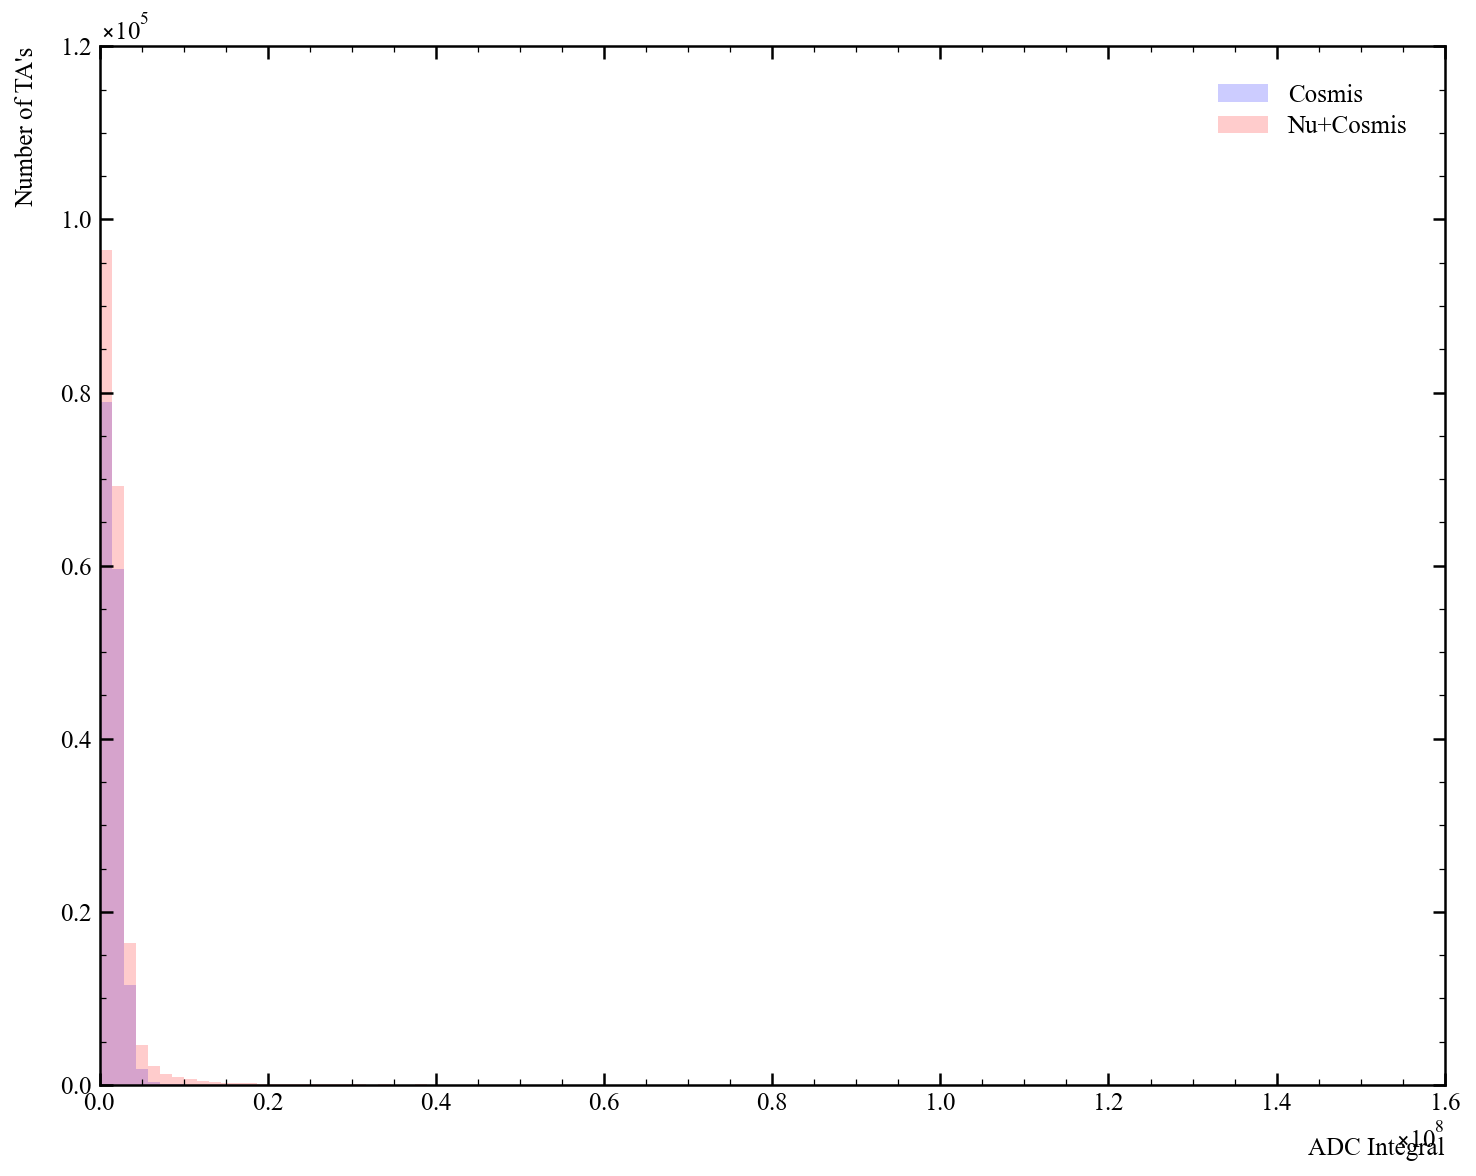

In [7]:
#producing the characteristics of TA's adc and TA count
adc_cos = []
adc_nu = []
for event in tree_cos:
    for adc in event.adc_integral:
        adc_cos.append(adc)
for event in tree_nu:
    for adc in event.adc_integral:
        adc_nu.append(adc)
adc_cos = np.array(adc_cos)
adc_nu = np.array(adc_nu)
fig, ax = plt.subplots(figsize = (10, 8))
bins = np.linspace(0, max(adc_cos.max(), adc_nu.max()), 100)
ax.hist(adc_cos, bins=bins, color='blue', alpha = 0.2, label='Cosmis')
ax.hist(adc_nu, bins=bins, color='red', alpha = 0.2, label='Nu+Cosmis')
ax.set_xlabel("ADC Integral")
ax.set_ylabel("Number of TA's")
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
def get_crp(ch):
    if 0<=ch<=3071: return 5
    elif 3072<=ch<=6143: return 4
    elif 6144<=ch<=9215: return 2
    elif 9216<=ch<=12287: return 3
    return -1
def build_crp_vector(tree):
    crp_data = {2: [], 3:[], 4:[], 5:[]}
    for event in tree:
        best_crp, best_sum = -1, -1.0
        adc_array = event.adc_integral
        chan_array = event.channel_peak
        for adc, ch in zip(adc_array, chan_array):
            crp = get_crp(int(ch))
            if crp<0:
                continue
            if adc>best_sum:
                best_sum = adc
                best_crp = crp
        if best_crp >=0:
            crp_data[best_crp].append(best_sum)
    for crp in crp_data:
        crp_data[crp].sort()
    return crp_data

# def build_crp_vector(tree):
#     crp_data = {2: [], 3:[], 4: [], 5: []}
#     for event in tree:
#         seen_crp = set()
#         adc_array = event.adc_integral
#         chan_array = event.channel_peak
#         for adc, ch in zip(adc_array, chan_array):
#             crp = get_crp(int(ch))
#             if crp<0:
#                 continue
#             if crp not in seen_crp:
#                 crp_data[crp].append(adc)
#                 seen_crp.add(crp)
#     for crp in crp_data:
#         crp_data[crp].sort()
#     return crp_data

print("Loading Cosmic...")
cosmic_crp = build_crp_vector(tree_cos)
print("Loading Nu_+Cosmic...")
nu_crp = build_crp_vector(tree_nu)

Loading Cosmic...
Loading Nu_+Cosmic...


In [9]:
for crp in [2, 3, 4, 5]:
    print(f"CRP {crp}- cosmic: {len(cosmic_crp[crp])}, nu_cosmic: {len(nu_crp[crp])}")

CRP 2- cosmic: 4475, nu_cosmic: 3212
CRP 3- cosmic: 4498, nu_cosmic: 3033
CRP 4- cosmic: 534, nu_cosmic: 1867
CRP 5- cosmic: 479, nu_cosmic: 1887


In [10]:
def calculate_eff(cos, nu, thr_min=1e6, n_thr=200):
    primary = np.array(cos)
    sec = np.array(nu)
    thr_max = max(primary.max(), sec.max())
    thresholds = np.linspace(thr_min, thr_max, n_thr)
    N_primary = float(len(primary))
    #N_primary = 250
    eff = np.array([
        100*np.sum(primary>=thr)/N_primary if N_primary >0 else 0.0
        for thr in thresholds
    ])
    return thresholds, eff

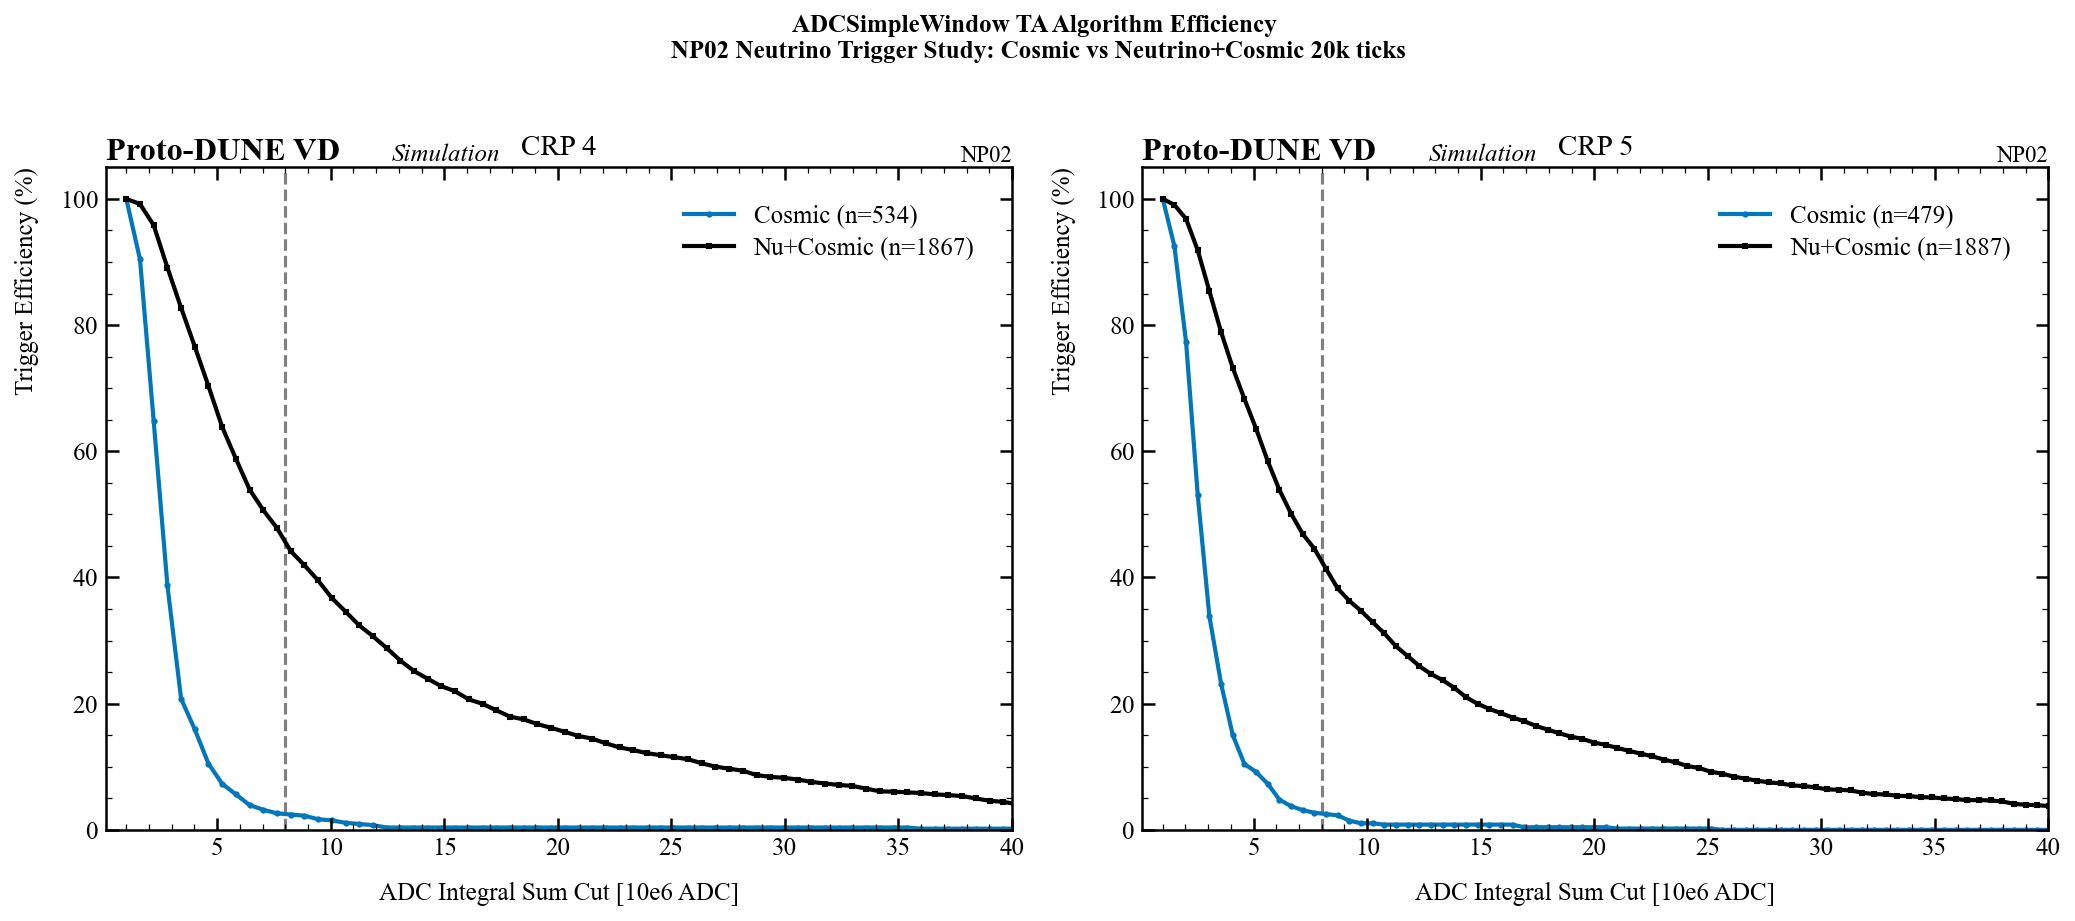

In [11]:
THR_MIN = 1e6
N_THR=200
CRPS=[4, 5]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("ADCSimpleWindow TA Algorithm Efficiency \n"
             "NP02 Neutrino Trigger Study: Cosmic vs Neutrino+Cosmic 20k ticks", 
             fontsize=12, fontweight='bold', y=1.02)
for ax, crp in zip(axes, CRPS):
    cos_data = cosmic_crp[crp]
    nu_data = nu_crp[crp]
    thr_cos, eff_cos = calculate_eff(cos_data, nu_data, THR_MIN, N_THR)
    thr_nu, eff_nu = calculate_eff(nu_data, cos_data, THR_MIN, N_THR)
    ax.plot(thr_cos, eff_cos, color='#0077BB', linewidth=2, marker='o', markersize=2, label=f'Cosmic (n={len(cos_data)})')
    ax.plot(thr_nu, eff_nu, color='#000000', linewidth=2, marker='s', markersize=2,linestyle='-', label=f'Nu+Cosmic (n={len(nu_data)})')
    
    #for 8m adc count
    ax.axvline(8e6, color='gray', linestyle='--', linewidth=1.5, zorder=1)
    
    ax.set_xlim(1e5, 40e6)
    ax.set_ylim(0, 105)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _:f'{x/1e6:.0f}'))
    ax.set_xlabel('ADC Integral Sum Cut [10e6 ADC]', loc='center')
    ax.set_ylabel("Trigger Efficiency (%)")
    ax.set_title(f'CRP {crp}')
    ax.legend(loc='upper right')
    hep.label.exp_label(exp='Proto-DUNE VD', rlabel='NP02', ax=ax)
plt.tight_layout()
#plt.savefig("Efficiency Plot for CRP4&CRP5.png", dpi=400)
plt.show()

Change from doing the per events searches for TA, switching to total number of TA generated

In [10]:
def build_bde_vector(tree):
    bde_cos = []
    bde_nu  = []
    data    = []
    for event in tree:
        best_crp, best_sum, best_ch = -1, -1.0, -1
        for adc, ch in zip(event.adc_integral, event.channel_peak):
            ch = int(ch)
            crp = get_crp(ch)
            if crp < 0:
                continue
            if adc > best_sum:
                best_sum = adc
                best_crp = crp
                best_ch  = ch
        # only keep if the best TA came from BDE (CRP 4 or 5, channels 0-6143)
        if best_ch >= 0 and best_ch <= 6143:
            data.append(best_sum)
    data.sort()
    return data

print("Loading Cosmic BDE...")
cosmic_bde = build_bde_vector(tree_cos)
print("Loading Nu+Cosmic BDE...")
nu_bde     = build_bde_vector(tree_nu)

print(f"BDE cosmic:    {len(cosmic_bde)}")
print(f"BDE nu+cosmic: {len(nu_bde)}")

Loading Cosmic BDE...
Loading Nu+Cosmic BDE...
BDE cosmic:    4
BDE nu+cosmic: 181


In [12]:
def kde_smooth(data, x_range, bandwidth=1.5):
    kde = KernalDensity(kernal='gaussian', bandwidth=bandwidth)
    kde.fit(np.array(data).reshape(-1, 1))
    log_dens = kde.score_samples(x_range.reshape(-1,1))
    density = np.exp(log_dens)
    return density/density.sum() * 100


max_ta = max(max(cos_ta_count), max(nu_ta_count))
bins = np.arange(0, max(30,max_ta+2))
fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle("TA per Event\nNP02 Cosmic vs NuCosmic", fontsize=11, fontweight='bold')
cos_hist, _ = np.histogram(cos_ta_count, bins=bins)
nu_hist, _ = np.histogram(nu_ta_count, bins=bins)
x = bins[:-1]
cos_y = cos_hist/len(cos_ta_count)*100
nu_y = nu_hist/len(nu_ta_count)*100

ax.plot(x, cos_y, color='#0077BB', lw=1.5, label='Cosmic')
ax.fill_between(x, cos_y, alpha=0.15, color='#0077BB')

ax.plot(x, nu_y, color='#CC3311', linestyle='--', lw=1.5, label='Nu+Cosmic')
ax.fill_between(x, nu_y, alpha=0.15, color='#CC3311')

#ax.bar(x-width/2, cos_hist/len(cos_ta_count)*100, width = width, color='#0077BB', alpha=0.8, label='Cosmic')
#ax.bar(x+width/2, nu_hist/len(nu_ta_count)*100, width=width, color='#CC3311', alpha=0.8, label='Nu+Cosmic')
ax.axvline(np.median(cos_ta_count), color='#0077BB', linestyle='--', lw=1.2, label=f'Median Cosmic={np.median(cos_ta_count):.0f}')
ax.axvline(np.median(nu_ta_count), color='#CC3311', linestyle='--', lw=1.2, label=f'Median Nu+Cosmic={np.median(nu_ta_count):.0f}')
ax.set_ylabel("Fraction of Events (%)")
ax.set_xlabel("Number of TAs Per Event")
ax.set_xticks(x[::5])
ax.set_xticklabels(x[::5])
ax.set_xlim(-1, max_ta+1)
#ax.set_xticklabels([str(int(b)) if b<bins[-2] else f'>={int(bins[-2])}' for b in x])
ax.legend()
hep.label.exp_label(exp='ProtoDUNE-VD', rlabel='NP02', ax=ax)
plt.tight_layout()
plt.savefig("TA's per Event.png", dpi=400)
plt.show()

NameError: name 'cos_ta_count' is not defined

In [13]:
thr_cos, eff_cos = calculate_eff(cosmic_bde)
thr_nu,  eff_nu  = calculate_eff(nu_bde)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
fig.suptitle("ADCSimpleWindow TA Algorithm Efficiency — BDE (CRP 4 + CRP 5)\n"
             "NP02 Neutrino Trigger Study: Cosmic vs Neutrino+Cosmic 20k ticks",
             fontsize=12, fontweight='bold', y=1.02)

ax.plot(thr_cos, eff_cos, color='#0077BB', linewidth=2, marker='o', markersize=2,
        label=f'Cosmic (n={len(cosmic_bde)})')
ax.plot(thr_nu,  eff_nu,  color='#CC0000', linewidth=2, marker='s', markersize=2,
        linestyle='--', label=f'$\\nu$ + Cosmic (n={len(nu_bde)})')

THR_MARK   = 8e6
idx_cos    = np.argmin(np.abs(thr_cos - THR_MARK))
idx_nu     = np.argmin(np.abs(thr_nu  - THR_MARK))
eff_cos_at = eff_cos[idx_cos]
eff_nu_at  = eff_nu[idx_nu]

ax.axvline(THR_MARK, color='grey', linestyle='--', linewidth=1.5, zorder=1)
# ax.axhline(eff_cos_at, color='#0077BB', linestyle=':', linewidth=1.2, alpha=0.7)
# ax.axhline(eff_nu_at,  color='#CC0000', linestyle=':', linewidth=1.2, alpha=0.7)
# ax.plot(THR_MARK, eff_cos_at, 'o', color='#0077BB', markersize=8, zorder=5)
# ax.plot(THR_MARK, eff_nu_at,  's', color='#CC0000', markersize=8, zorder=5)
# ax.annotate(f'{eff_cos_at:.1f}%', xy=(THR_MARK, eff_cos_at),
#             xytext=(THR_MARK * 1.3, eff_cos_at + 3),
#             color='#0077BB', fontsize=10, fontweight='bold',
#             arrowprops=dict(arrowstyle='->', color='#0077BB', lw=1.2))
# ax.annotate(f'{eff_nu_at:.1f}%', xy=(THR_MARK, eff_nu_at),
#             xytext=(THR_MARK * 1.3, eff_nu_at - 6),
#             color='#CC0000', fontsize=10, fontweight='bold',
#             arrowprops=dict(arrowstyle='->', color='#CC0000', lw=1.2))
# ax.text(THR_MARK * 1.05, 102, '8M ADC', fontsize=9, color='grey', va='top')


ax.set_ylim(0, 110)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}'))
ax.set_xlabel('ADC Integral Sum Cut [×10e6 ADC]', loc='center')
ax.set_ylabel('Trigger Efficiency (%)')
ax.set_title('BDE (CRP 4 + CRP 5)')
ax.legend(loc='upper right')
hep.label.exp_label(exp='Proto-DUNE VD', rlabel='NP02', ax=ax)

plt.tight_layout()
ax.set_xlim(0.5e5, 40e6)
plt.savefig("ADC Simple Window BDE.png", dpi=400)
plt.show()

NameError: name 'cosmic_bde' is not defined

In [14]:
import collections
def count_tas_per_event(tree):
    counts = []
    for event in tree:
        n_ta = 0
        for ch in event.channel_peak:
            if get_crp(int(ch)) >=0:
                n_ta +=1
        counts.append(n_ta)
    return counts
cos_ta_count = count_tas_per_event(tree_cos)
nu_ta_count = count_tas_per_event(tree_nu)


In [15]:
def build_crp_vector_ta(tree):
    crp_data = {2: [], 3:[], 4:[], 5:[]}
    for event in tree:
        for adc, ch in zip(event.adc_integral, event.channel_peak):
            crp = get_crp(int(ch))
            if crp <0:
                continue
            crp_data[crp].append(float(adc))
    for crp in crp_data:
        crp_data[crp].sort()
    return crp_data
cosmic_crp = build_crp_vector_ta(tree_cos)
nu_crp = build_crp_vector_ta(tree_nu)

In [44]:
def calculate_eff(data, thr_min=1e6, n_thr=200):
    thresholds = np.linspace(thr_min, max(data), n_thr)
    eff = [100.0*np.sum(np.array(data) >=t) /len(data) for t in thresholds]
    return thresholds, eff

In [39]:
for crp in [2, 3, 4, 5]:
    print(f"CRP {crp}: cosmic: {len(cosmic_crp[crp])}, nu_cosmic: {len(nu_crp[crp])}")

CRP 2: cosmic: 1345, nu_cosmic: 1402
CRP 3: cosmic: 1230, nu_cosmic: 1407
CRP 4: cosmic: 614, nu_cosmic: 925
CRP 5: cosmic: 590, nu_cosmic: 972


Cosmic Efficiency @ 8e6: 0.2% (n = 614)
Nu Efficiency @ 8e6: 0.1% (n= 614)
Cosmic Efficiency @ 8e6: 0.2% (n = 590)
Nu Efficiency @ 8e6: 0.1% (n= 590)


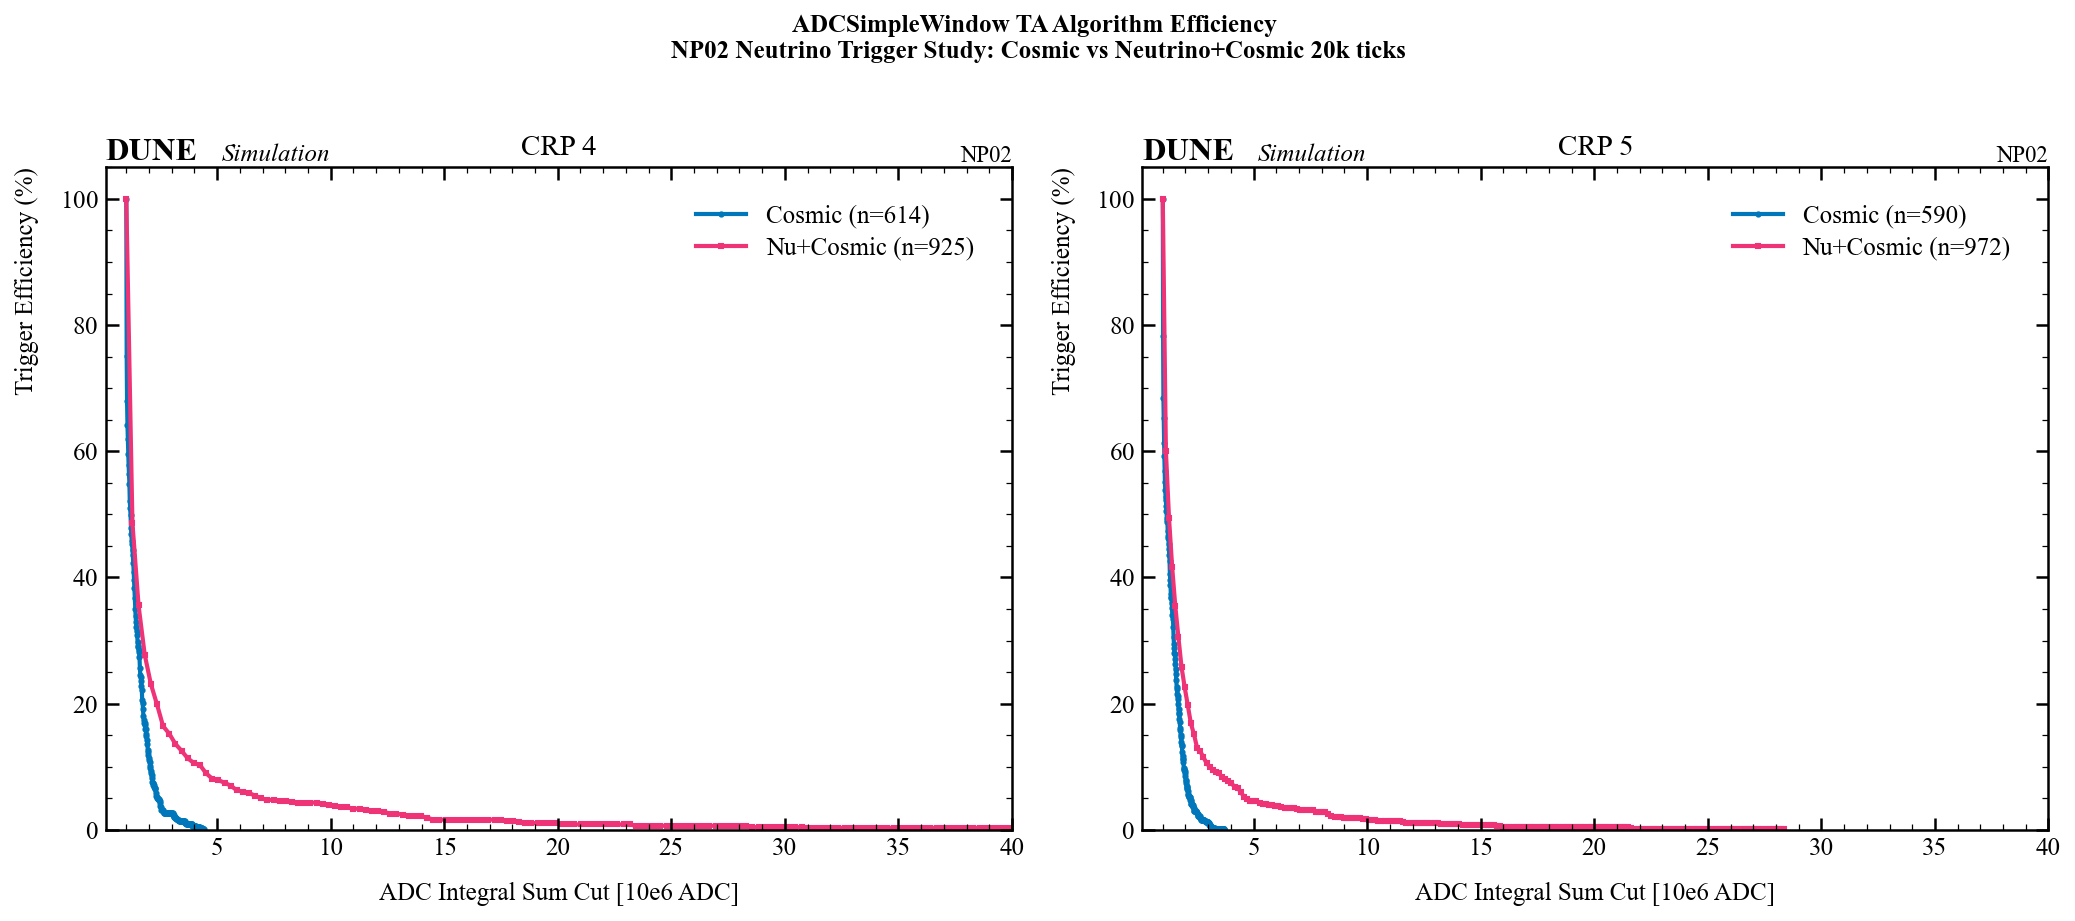

In [42]:
THR_MIN = 1e6
N_THR=200
CRPS=[4, 5]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("ADCSimpleWindow TA Algorithm Efficiency \n"
             "NP02 Neutrino Trigger Study: Cosmic vs Neutrino+Cosmic 20k ticks", 
             fontsize=12, fontweight='bold', y=1.02)
for ax, crp in zip(axes, CRPS):
    cos_data = cosmic_crp[crp]
    nu_data = nu_crp[crp]
    thr_cos, eff_cos = calculate_eff(cos_data, THR_MIN, N_THR)
    thr_nu, eff_nu = calculate_eff(nu_data, THR_MIN, N_THR)
    
    #printing for at 8M adc threshold
    idx_cos = np.argmin(np.abs(np.array(thr_cos)-1e8))
    idx_nu = np.argmin(np.abs(np.array(thr_nu)-1e8))
    print(f"Cosmic Efficiency @ 8e6: {eff_cos[idx_cos]:.1f}% (n = {len(cos_data)})")
    print(f"Nu Efficiency @ 8e6: {eff_nu[idx_nu]:.1f}% (n= {len(cos_data)})")
    
    ax.plot(thr_cos, eff_cos, color='#0077BB', linewidth=2, marker='o', markersize=2, label=f'Cosmic (n={len(cos_data)})')
    ax.plot(thr_nu, eff_nu, color='#EE3377', linewidth=2, marker='s', markersize=2, label=f'Nu+Cosmic (n={len(nu_data)})')
    ax.set_xlim(1e5, 40e6)
    ax.set_ylim(0, 105)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _:f'{x/1e6:.0f}'))
    ax.set_xlabel('ADC Integral Sum Cut [10e6 ADC]', loc='center')
    ax.set_ylabel("Trigger Efficiency (%)")
    ax.set_title(f'CRP {crp}')
    ax.legend(loc='upper right')
    hep.label.exp_label(exp='DUNE', rlabel='NP02', ax=ax)
plt.tight_layout()
plt.show()